# DVR + Complex Scaling Test for $\langle r^2\rangle(L)$

In [1]:
from dvr import *

In [2]:
# define system parameters
n = 256                      # number of DVR grid points
phi = pi / 24                # rotation angle
real_res = 1.606 - 1j*0.047  # expected value of resonance
L = 50.0                     # system size
save_plots = True           # save plots or not


gauss_s = lambda r: 2.0 * exp(-((r-3.0)/1.5)**2) # potential

In [3]:
# compute <r^2> as L varies
Ls = np.linspace(20.0, 50.0, 150)
rrs = []

for L in Ls:
    DVRtest = DVR(n, L, rotation_angle=phi, potential=gauss_s)
    _, eigstate = DVRtest.closest_to_resonance(real_res)
    rr = DVRtest.compute_r2(eigstate[:, 0], rotate_rr=True)
    rrs.append(rr)

print(f"Radius of resonance at L = {Ls[-1]} is <r^2> = {rrs[-1].real:.3f} + i{rrs[-1].imag:.3f}.")

Radius of resonance at L = 50.0 is <r^2> = 0.774 + i0.200.


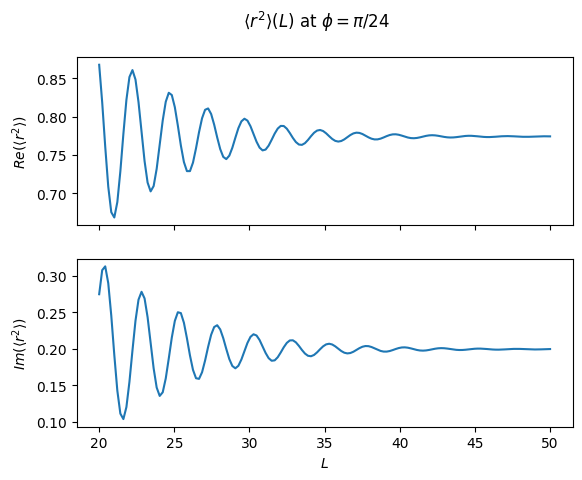

In [4]:
# plot <r^2>(L)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(Ls, np.real(rrs), label=r"$Re(\langle r^2\rangle)$")
ax2.plot(Ls, np.imag(rrs), label=r"$Im(\langle r^2\rangle)$")
ax1.set_ylabel(r"$Re(\langle r^2\rangle)$")
ax2.set_ylabel(r"$Im(\langle r^2\rangle)$")
ax2.set_xlabel(r"$L$")
fig.suptitle(r"$\langle r^2\rangle(L)$ at $\phi=\pi/24$")
if save_plots:
    plt.savefig(f"./plots/exact_radius_vs_L.png")
plt.show()

In [5]:
# compute <r^2> as phi varies
# the ABC theorem says that this should be const.
phis = np.linspace(pi/24, pi/6, 50)
rrs = []

for phi in phis:
    DVRtest = DVR(n, L, rotation_angle=phi, potential=gauss_s)
    _, eigstate = DVRtest.closest_to_resonance(real_res)
    rr = DVRtest.compute_r2(eigstate[:, 0], rotate_rr=True)
    rrs.append(rr)

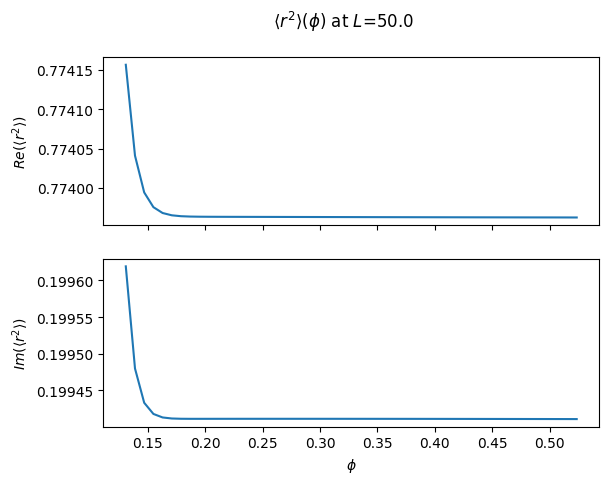

In [6]:
# plot <r^2>(phi)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(phis, np.real(rrs), label=r"$Re(\langle r^2\rangle)$")
ax2.plot(phis, np.imag(rrs), label=r"$Im(\langle r^2\rangle)$")
ax1.set_ylabel(r"$Re(\langle r^2\rangle)$")
ax2.set_ylabel(r"$Im(\langle r^2\rangle)$")
ax2.set_xlabel(r"$\phi$")
fig.suptitle(r"$\langle r^2\rangle(\phi)$ at $L$=50.0")
if save_plots:
    plt.savefig(f"./plots/exact_radius_vs_phi.png")
plt.show()